# 6/26 Razor Test 1
### Notes:
Collimitor face to reflection off wedge 95mm  
Wedge to mirror 135mm  
Mirror to lens 142mm  
Lens to blade 66 mm  
Blad e4to sensor 200mm  
Focal length 50mm 1in dia  
Computational dist:     |   d1: 326.57  (320.5 face to d1)|   d2: 55.32 |   Path: 375.82  
Measured distances:     |   d1: (372)                     |   d2: 66    |   Path: 438  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [3]:
df = pd.read_csv('data/razor_data.csv')
df['Power (mW)'] = pd.to_numeric(df['Power (mW)'])
df['Distance (mm)'] = pd.to_numeric(df['Distance (mm)'])
df_clean = df.dropna().copy()

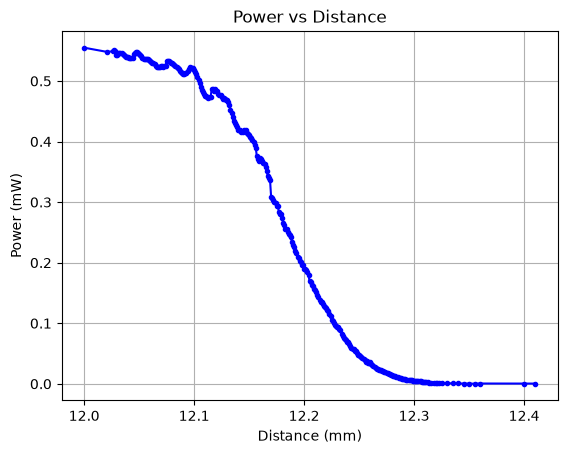

In [4]:
plt.plot(df_clean['Distance (mm)'], df_clean['Power (mW)'], marker='.', linestyle='-', color='blue')

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

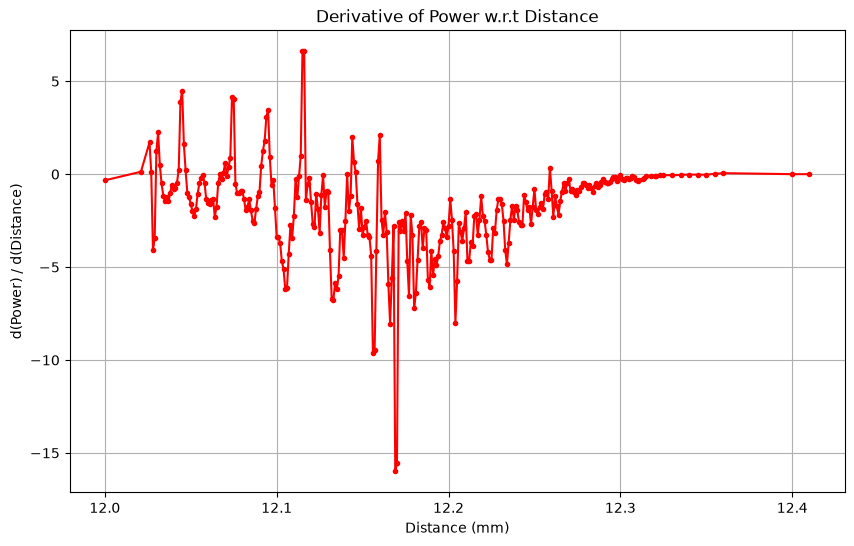

In [5]:
df_clean = df_clean.sort_values('Distance (mm)').reset_index(drop=True)

df_clean['Derivative'] = np.gradient(df_clean['Power (mW)'], df_clean['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df_clean['Distance (mm)'], df_clean['Derivative'], color='red', marker='.')

plt.title('Derivative of Power w.r.t Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Power) / d(Distance)')
plt.grid(True)

plt.show()

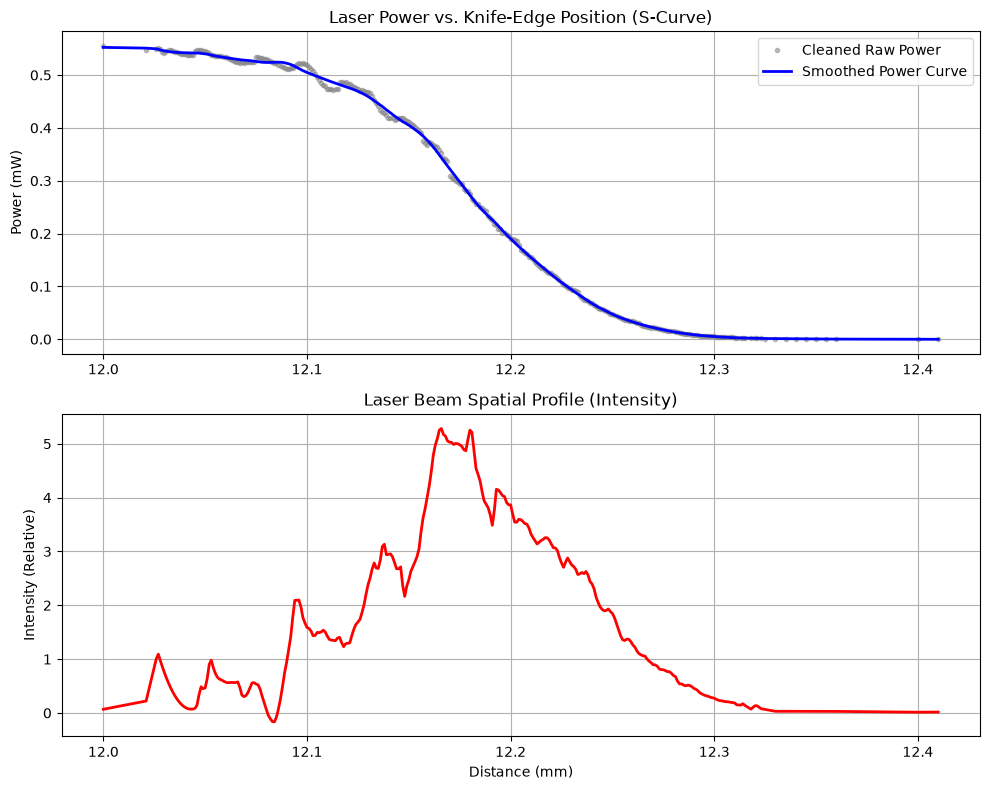

In [6]:
df_clean = df.dropna().sort_values('Distance (mm)').reset_index(drop=True)

window = 5
rolling_median = df_clean['Power (mW)'].rolling(window=window, center=True).median()
outlier_idx = np.abs(df_clean['Power (mW)'] - rolling_median) > 0.05 
df_clean.loc[outlier_idx, 'Power (mW)'] = np.nan
df_clean = df_clean.dropna().reset_index(drop=True)

smoothed_power = savgol_filter(df_clean['Power (mW)'], window_length=45, polyorder=3)

beam_profile = -1 * np.gradient(smoothed_power, df_clean['Distance (mm)'])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
ax1.plot(df_clean['Distance (mm)'], df_clean['Power (mW)'], '.', label='Cleaned Raw Power', color='grey', alpha=0.5)
ax1.plot(df_clean['Distance (mm)'], smoothed_power, label='Smoothed Power Curve', color='blue', linewidth=2)
ax1.set_title('Laser Power vs. Knife-Edge Position (S-Curve)')
ax1.set_ylabel('Power (mW)')
ax1.grid(True)
ax1.legend()

ax2.plot(df_clean['Distance (mm)'], beam_profile, color='red', linewidth=2)
ax2.set_title('Laser Beam Spatial Profile (Intensity)')
ax2.set_xlabel('Distance (mm)')
ax2.set_ylabel('Intensity (Relative)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 6/29 Razor Test 2
### Notes:
Collimitor face to reflection off wedge 85mm  
Wedge to mirror 133mm  
Mirror to lens 102.5mm  
Lens to blade 56 mm  
Blad e4to sensor 200mm  
Focal length 50mm 1in dia  
Computational dist:     |   d1: 326.57  (320.5 face to d1)|   d2: 55.32 |   Path: 375.82  
Measured distances:     |   d1: (320.5)                   |   d2: 56    |   Path: 376.5  

In [7]:
df2 = pd.read_csv('data/razor_data2.csv')
df2['Power (mW)'] = pd.to_numeric(df2['Power (mW)'])
df2['Distance (mm)'] = pd.to_numeric(df2['Distance (mm)'])
df2_clean = df2.dropna().copy()

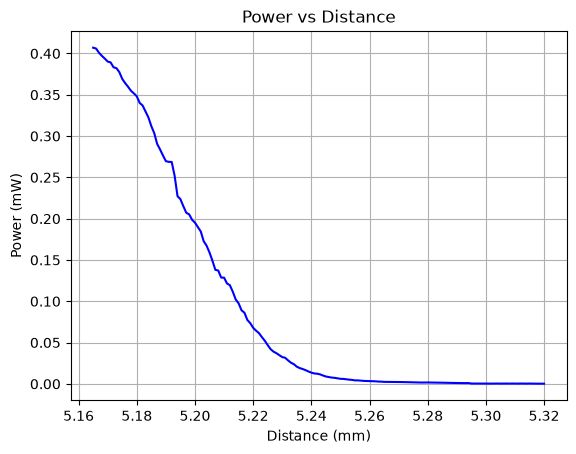

In [8]:
plt.plot(df2_clean['Distance (mm)'], df2_clean['Power (mW)'],color='blue')

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

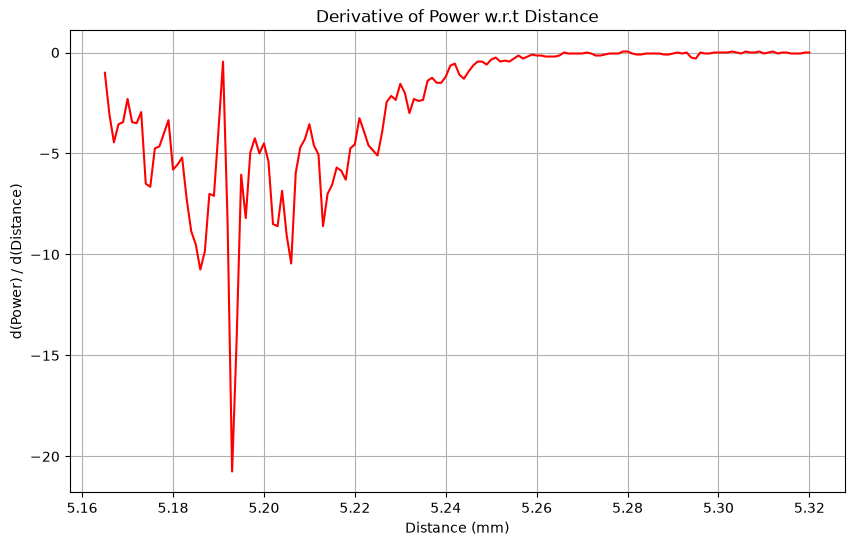

In [9]:
df2_clean = df2_clean.sort_values('Distance (mm)').reset_index(drop=True)

df2_clean['Derivative'] = np.gradient(df2_clean['Power (mW)'], df2_clean['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df2_clean['Distance (mm)'], df2_clean['Derivative'], color='red')

plt.title('Derivative of Power w.r.t Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Power) / d(Distance)')
plt.grid(True)

plt.show()

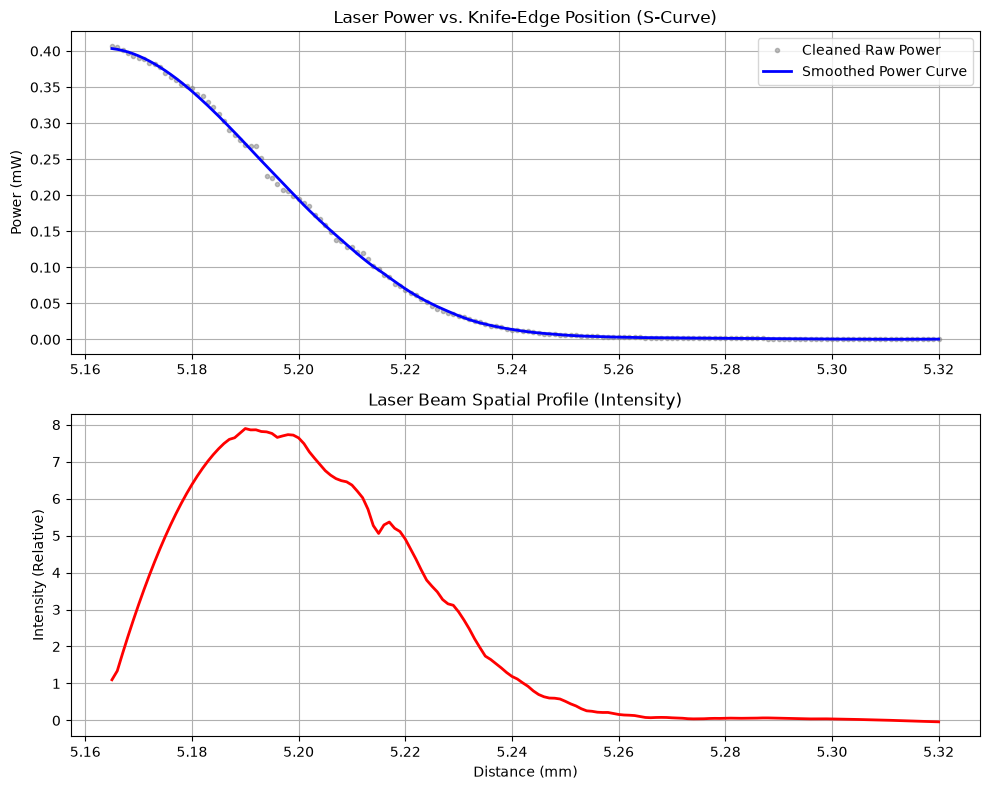

In [10]:
df2_clean = df2.dropna().sort_values('Distance (mm)').reset_index(drop=True)

window = 5
rolling_median = df2_clean['Power (mW)'].rolling(window=window, center=True).median()
outlier_idx = np.abs(df2_clean['Power (mW)'] - rolling_median) > 0.05 
df2_clean.loc[outlier_idx, 'Power (mW)'] = np.nan
df2_clean = df2_clean.dropna().reset_index(drop=True)

smoothed_power = savgol_filter(df2_clean['Power (mW)'], window_length=45, polyorder=3)

beam_profile = -1 * np.gradient(smoothed_power, df2_clean['Distance (mm)'])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
ax1.plot(df2_clean['Distance (mm)'], df2_clean['Power (mW)'], '.', label='Cleaned Raw Power', color='grey', alpha=0.5)
ax1.plot(df2_clean['Distance (mm)'], smoothed_power, label='Smoothed Power Curve', color='blue', linewidth=2)
ax1.set_title('Laser Power vs. Knife-Edge Position (S-Curve)')
ax1.set_ylabel('Power (mW)')
ax1.grid(True)
ax1.legend()

ax2.plot(df2_clean['Distance (mm)'], beam_profile, color='red', linewidth=2)
ax2.set_title('Laser Beam Spatial Profile (Intensity)')
ax2.set_xlabel('Distance (mm)')
ax2.set_ylabel('Intensity (Relative)')
ax2.grid(True)

plt.tight_layout()
plt.show()